# Lec-5: Neural Networks
- Model mathematical function from input to outputs based on the structure and parameters of the network.
- Allows for learning the network's parameters based on data.

$$
h(x_{1}, x_{2}) = w_{0} + w_{1}x_{1} + w_{2}x_{2}
$$

- Here $h$ is our hypothesis.
- Think of $w_{1}$ and $w_{2}$ that puts weights on inputs $x_{1}$ and $x_{2}$.
- Think of $w_{0}$ as some sort of bias.

**Activation Function:**
The function that determines when to activate the neurons.
- **Logistic Sigmoid:**
  - $g(x) = \frac{e_{x}}{e^{x} + 1}$
    - Usually used before or close to output layers, when _vanishing gradient[1] is less of an issue_.
    - It outputs values between 0 and 1, making it ideal for probability estimation.
    - It's smooth and differentiable, which is good for gradient-based optimization.
    
    <img src="image.png" alt="sigmoid" width="30%" height="auto">   

- **Rectified Linear Unit (ReLU):**
  - $g(x) = \max(0,x)$.
    - Usually used within the Hidden layers
    - It helps avoid _vanishing gradients_[1], which is a common issue with sigmoid.
    - It's computationally efficient.
    - It introduces non-linearity while keeping the model simple.
    - It allows for _sparse activation_, which can improve generalization.
    
    <img src="image-1.png" alt="Relu" width="30%" height="auto">   

**Simple Example of NN: Calculate the `OR` Function**   
<img src="image-2.png" alt="NN-1" width="30%" height="auto">   

- `OR` Function: $1$ if any is $1$, $0$ if both are $0$.   
<img src="image-3.png" alt="NN-2" width="30%" height="auto">  

**General Structure of NN:**   
<img src="image-4.png" alt="NN-gen" width="30%" height="auto">  

**Gradient Descent:**   
- Algo for minimizing _loss_ when training neural network.
  - Start with a random choice of weights
    - Repeat:
      - calculate the gradient based on _all data points_(expensive): which direction that will lead to decreasing loss
      - Update weights according to the gradient

**Stochastic Gradient Descent:**   
- Algo for minimizing _loss_ when training neural network.
  - Start with a random choice of weights
    - Repeat:
      - calculate the gradient based on _one data point_(less expensive, not efficient): which direction that will lead to decreasing loss
      - Update weights according to the gradient

**Mini-batch Gradient Descent:**   
- Algo for minimizing _loss_ when training neural network.
  - Start with a random choice of weights
    - Repeat:
      - calculate the gradient based on _one small batch_(practical): which direction that will lead to decreasing loss
      - Update weights according to the gradient.

**NN can be used to train which action to take in RL:**   
<img src="image-5.png" alt="NN-RL" width="30%" height="auto">  

- Perceptron can only capable of learning linearly separable decision boundary.
- But multi-layer neural network can do this nonlinearly.
  - **Deep Neural Network:** with multiple hidden layers.


**Backpropagation:**   
- Start with a random choice of weights.
- Repeat:
  - Calculate error for output layer.
  - For each layer, starting with output layer, and moving inwards towards earliest layer:
    - Propagate error back one layer.
    - Update weights.


**Overfitting:**   
- Fitting too close to the training data or input data, doesn't allow us to generalize.
  - **Dropout:**
    - Temporarily removing units - selected at random - from a neural network to prevent over-reliance on certain units.  
    <img src="image-6.png" alt="dropout" width="30%" height="auto">  





In [ ]:
# TODO Code (Tensorflow)

## Computer Vision
- Representing image with numbers $0-255$, or $3\times (0 \text{ to } 255)$ for color image in RGB space. 
- Problem with this, the input layer would be huge.
- Another problem, we are loosing structural information about the image. Like which pixel comes after which pixel, or which pixels are surrounding which pixel, etc.   

<img src="image-7.png" alt="imageNN" width="30%" height="auto">   

**Image Convolution:**
- Applying a filter that adds each pixel value of an image to its neighbors, weighted according to a _KERNEL_ matrix.
  - We use to do image manupulation by sliding the KERNEL over the image and perform convolution at each location.
- Here is an example of a _KERNEL_ used for edge detection.
  - If neighboring pixels are similar to middle pixel, lets say all are 20, then convolution tends to zero(=0).
  - If neighboring pixels are different than middle pixel, lets say like in the picture, then convolution tends to large +v2 number. An indication of an edge being found.   
  <img src="image-8.png" alt="convolution" width="30%" height="auto">   



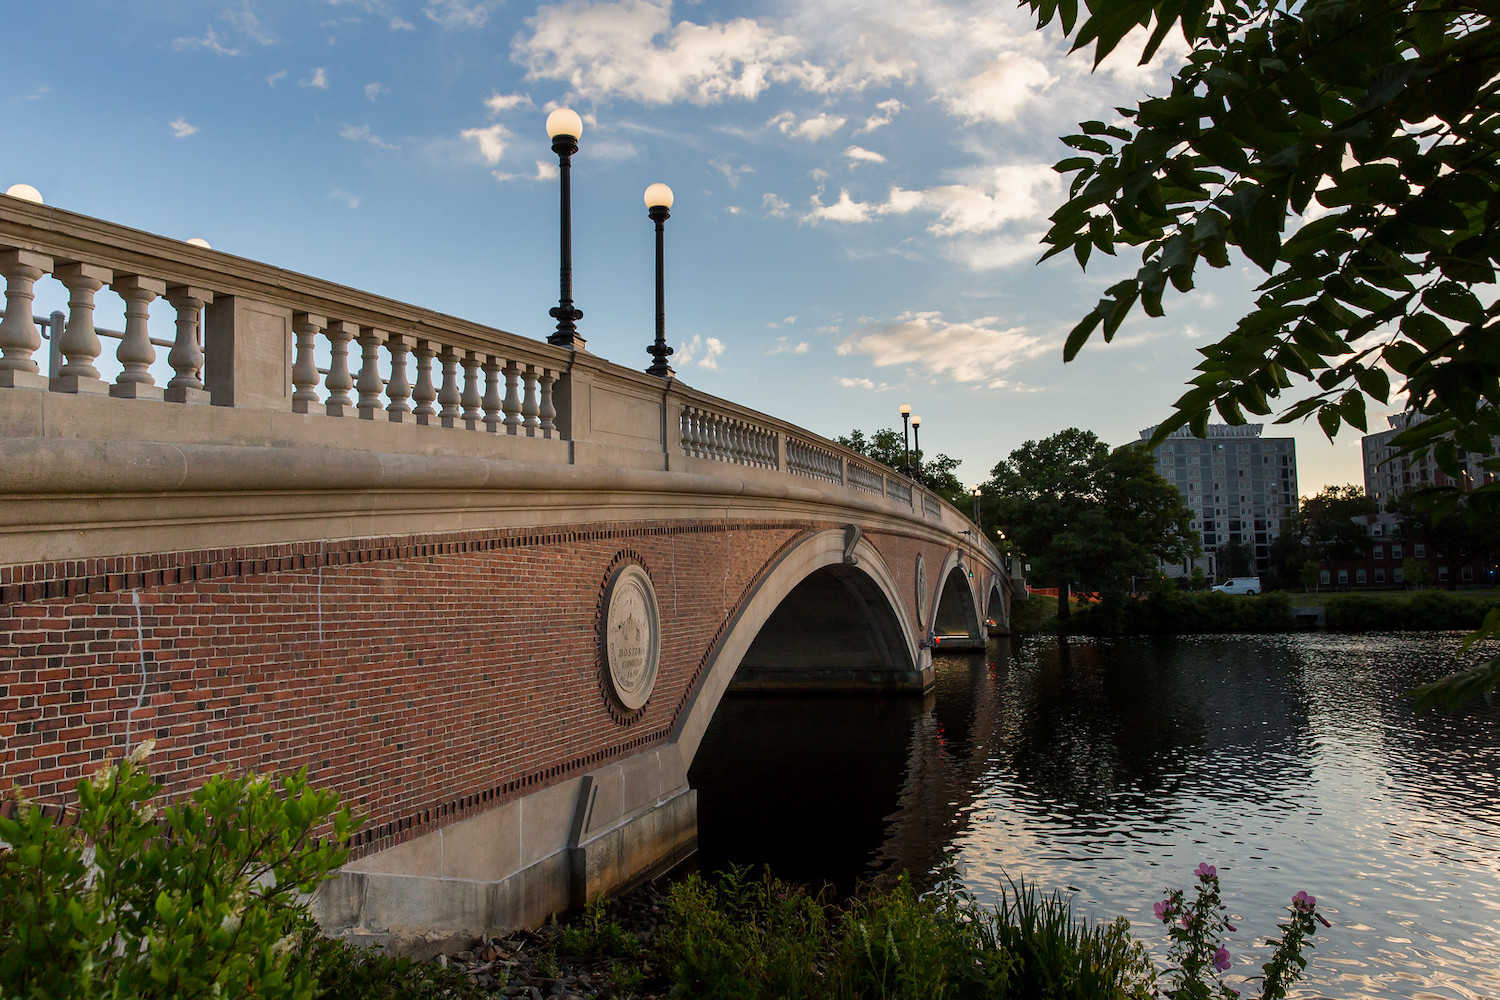

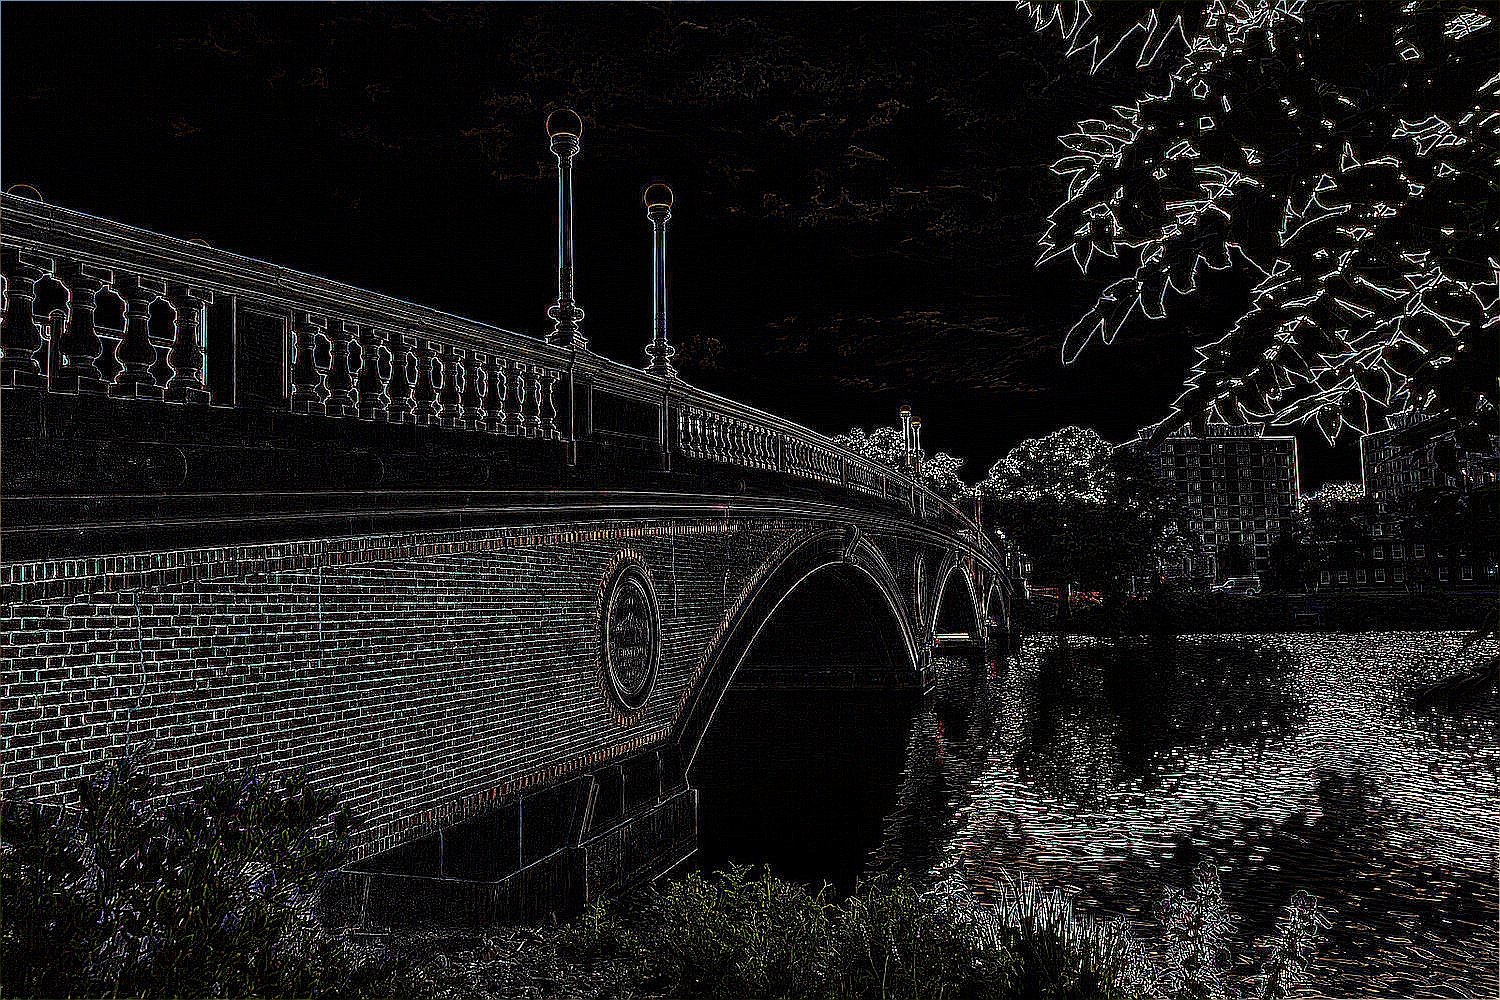

In [17]:
# Edge detection in Jupyter Notebook
from PIL import Image, ImageFilter
from IPython.display import display

# Provide the image path directly
image_path = "src5/convolution/bridge.png"  # Update this to your actual path

# Open and convert image to RGB
image = Image.open(image_path).convert("RGB")

# Apply edge detection kernel
filtered = image.filter(ImageFilter.Kernel(
    size=(3, 3),
    kernel=[-1, -1, -1,
            -1,  8, -1,
            -1, -1, -1],
    scale=1,
    offset=0
))

# # Display the original and filtered images
# image.show(title="Original Image")
# filtered.show(title="Edge Detected Image")


# # Resize images (e.g., 50% smaller)
# new_size = (image.width // 2, image.height // 2)
# image_resized = image.resize(new_size)
# filtered_resized = filtered.resize(new_size)

# Show inline (Jupyter)
display(image)
display(filtered)





**Pooling:**
- Reducing the size of an input by sampling from regions in the input.
- **Max Pooling:**
  - Pooling by choosing the maximum value in each region.
  - Example: 2x2 max pooling:   
    <img src="image-9.png" alt="maxpooling" width="30%" height="auto">   



## Convolutional Neural Network:
- Start with input image.
- Then do convolution -> image map, multiple times. each time we extract different feature of the image.
- Pooling: reduce sizes of these feature maps. max -pooling or avg-pooling.
- Flattening.
- Implement NN with flattened values as input.   
<img src="image-10.png" alt="ConvNN" width="50%" height="auto">  

- In practice we might do _Convolution + Pooling_ steps multiple times. Because real images might have lot more data and we need to systematically reduce the number of valuable workable flattened datasets.   
<img src="image-12.png" alt="ConvNN-multi" width="50%" height="auto">  




### Hand-writting Recognition

In [ ]:
# imports
import sys
import tensorflow as tf

print(tf.__version__)

AttributeError: module 'tensorflow' has no attribute '__version__'

In [27]:
# TODO Handwritting recognition

---   
# Addendum
1. **Vanishing Gradient Problem of Sigmoid:**
    - In deep networks, especially those using activation functions like sigmoid or tanh, the gradients can become very small as they propagate backward through each layer. Eventually, they become so tiny that they effectively vanish — meaning:
        - Earlier layers in the network learn very slowly or not at all.
        - The network struggles to improve its performance.
        - Training becomes inefficient or fails altogether.
    - Activation functions like sigmoid squash input values into a small range (e.g., 0 to 1). When the input is far from zero, the derivative of the sigmoid becomes very small:
    $$
    sig(x) = \frac{1}{1+e^{-x}},\\
    sig'(x) = sig(x)(1-sig(x))
    $$   
    - So, for large or small values of x, the derivative approaches zero. When you multiply many small derivatives together (as happens during backpropagation in deep networks), the result becomes exponentially smaller, leading to vanishing gradients.